# 06 — Targeted readouts (Phase 5)

Three of the four stain targets — *Vim*, *Acta2*, *Atp1a1* — are **not on the 5K panel**, so for them the images
are the only per-cell measurement (CD45/*Ptprc* is on the panel, but the protein was undetectable, notebook 03).

1. **Astrocyte reactivity: protein vs RNA.** Protein score from αSMA/Vim (vimentin in astrocytes) vs a
   transcriptional reactivity score; where and when do they disagree?
2. **Leukocyte polarity, perivascular vs parenchymal** — magnitude and direction relative to the nearest vessel.
3. **18S rRNA per cell type, lesion vs physiological** — with and without adjusting for transcript density
   (is it ribosome biology or RNA quality?).
4. **Neuropil-loss index** — ATP1A1 in each cell's extracellular territory relative to the same section's
   physiological tissue of the same class (WM/GM): a tissue-damage readout the transcriptome cannot give.

All per-animal statistics: one value per animal, Wilcoxon signed-rank across animals.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
from scipy.stats import spearmanr, wilcoxon
from skimage.segmentation import find_boundaries

from beyondboundaries import data, plotting
from beyondboundaries import orthogonality as orth
from beyondboundaries.io import XeniumBundle, find_bundles

plotting.style()
SRC = "notebooks/06_targeted_readouts.ipynb"
OUT = ROOT / "results" / "06_targeted_readouts"
OUT.mkdir(parents=True, exist_ok=True)
CH = data.CHANNELS
cfg = data.load_config()

fa = pd.read_parquet(ROOT / "data" / "features_norm.parquet")
fa = fa[fa.segmentation_method == "Segmented by interior stain (18S)"].copy()
fa["lesion"] = fa.Curated_niche_state.astype(str).str.startswith("Lesion")
fa["phys"] = fa.Curated_niche_state.astype(str) == "Physiological"
fa["lesion_dist_um"] = orth.lesion_distance(fa, fa.lesion.values)
fa["region_class"] = np.select([fa.Global_anatomical_region.isin(["WM", "WM_Meningeal"]),
                                fa.Global_anatomical_region.isin(["GM", "DorsalHorn", "VentralHorn"])], ["WM", "GM"], "other")
STAGE_ORDER = ["CFA", "NONSYMPTOM", "OS1", "MILD16", "PEAK1", "PEAK2", "PEAK3", "SEVERE16", "SEVERE30",
               "REMISSION1", "REMISSION2"]
adata = ad.read_h5ad(ROOT / cfg["annotation"]["h5ad"])


def section_z(s: pd.Series, by: pd.Series) -> pd.Series:
    """Robust z within section (median / MAD) — removes staining batch, keeps within-section biology."""
    med = s.groupby(by, observed=True).transform("median")
    mad = (s - med).abs().groupby(by, observed=True).transform("median") * 1.4826
    return (s - med) / mad.replace(0, np.nan)


def per_animal_paired(df, value, a_mask, b_mask, min_n=20):
    rows = []
    for an, g in df.groupby("sample_name", observed=True):
        A, B = g.loc[a_mask[g.index], value], g.loc[b_mask[g.index], value]
        if len(A) >= min_n and len(B) >= min_n:
            rows.append(dict(animal=an, a=A.median(), b=B.median()))
    d = pd.DataFrame(rows)
    if len(d) < 5:
        return d, np.nan
    return d, wilcoxon(d.a - d.b).pvalue

## 1. Astrocyte reactivity — protein (vimentin channel) vs RNA

In [2]:
REACTIVE = ["C3", "Gfap", "Serpina3n", "Cd44", "Osmr", "Timp1", "Socs3", "Serping1", "H2-D1", "Psmb8", "Gbp2"]
HOMEO = ["Slc1a3", "Kcnj10", "Slc6a11", "Fgfr3", "Gjb6", "Aldoc", "Aldh1l1"]
ast = fa[fa.Anno_L1_curated == "Astrocyte"].copy()
Xln = orth.lognorm(adata[ast.index].X)
gi = {g: i for i, g in enumerate(adata.var_names)}


def gene_z(genes):
    M = Xln[:, [gi[g] for g in genes]].toarray()
    return ((M - M.mean(0)) / M.std(0)).mean(1)


ast["rna_reactive"] = gene_z(REACTIVE)
ast["rna_homeostatic"] = gene_z(HOMEO)
ast["rna_score"] = section_z(pd.Series(ast.rna_reactive - ast.rna_homeostatic, index=ast.index), ast.section_id)
# protein score: vimentin-channel intensity (cell mean, cytoplasmic p90) up, ATP1A1 rim down (spec)
ast["z_vim"] = section_z(ast.smavim_cell_mean, ast.section_id)
ast["z_vim90"] = section_z(ast.smavim_cyto_p90, ast.section_id)
ast["z_bndrim"] = section_z(ast.bnd_rim_mean, ast.section_id)
ast["prot_score"] = (ast.z_vim + ast.z_vim90 - ast.z_bndrim) / 3
print("protein score components vs RNA score (Spearman):",
      {c: round(spearmanr(ast[c], ast.rna_score, nan_policy="omit").statistic, 3) for c in ("z_vim", "z_vim90", "z_bndrim")})
r_all = spearmanr(ast.prot_score, ast.rna_score, nan_policy="omit").statistic
per_sec = ast.groupby("section_id").apply(lambda g: spearmanr(g.prot_score, g.rna_score, nan_policy="omit").statistic,
                                          include_groups=False)
print(f"protein vs RNA reactivity, Spearman ρ = {r_all:.3f} (per-section median {per_sec.median():.3f}, "
      f"range {per_sec.min():.2f}–{per_sec.max():.2f}); n = {len(ast):,}")
gene_rho = pd.Series({g: spearmanr(Xln[:, gi[g]].toarray().ravel(), ast.prot_score, nan_policy="omit").statistic
                      for g in REACTIVE + HOMEO}).sort_values()
gene_rho.round(3)

protein score components vs RNA score (Spearman): {'z_vim': np.float64(0.441), 'z_vim90': np.float64(0.617), 'z_bndrim': np.float64(0.139)}
protein vs RNA reactivity, Spearman ρ = 0.482 (per-section median 0.479, range 0.17–0.58); n = 47,062


Slc6a11     -0.440
Aldoc       -0.369
Gjb6        -0.351
Fgfr3       -0.347
Kcnj10      -0.259
Aldh1l1     -0.005
Slc1a3       0.124
Psmb8        0.158
H2-D1        0.186
Socs3        0.190
Gbp2         0.201
Osmr         0.262
Timp1        0.288
Cd44         0.333
Serpina3n    0.348
Gfap         0.384
Serping1     0.386
C3           0.504
dtype: float64

> **Finding — vimentin-channel protein agrees moderately with RNA reactivity** (ρ = 0.48; per section 0.17–0.58). Best
> single genes: *C3* (0.50), *Serping1* (0.39), *Gfap* (0.38); homeostatic genes anti-correlate (*Slc6a11* −0.44,
> *Aldoc* −0.37). The agreement comes from the vimentin channel (components ρ 0.44 / 0.62), not the ATP1A1 rim (0.14).
> Note *Vim* itself is not on the 5K panel — the image is the only vimentin measurement.

The protein score follows the spec (vimentin channel up, ATP1A1 rim down); the table below shows its components
per quadrant so it is clear which drives a cell into "protein-only".

Quadrants (top/bottom 25 % within section of each score): concordant reactive, concordant quiet,
**protein-only** (vimentin-high, RNA-quiet) and **RNA-only**. Where are they, and in which disease stages?

,n,lesion_frac,WM_frac,lesion_dist_median,edge_um_median,area_median,transcripts_median,vim_channel_z,vim_cyto_p90_z,atp1a1_rim_z,rna_reactive_median,rna_homeostatic_median
quadrant,,,,,,,,,,,,
both high,5853,0.950,0.856,0.000,101.389,88.190002,1558.0,6.340,6.080,0.433,0.621,-0.638
protein-only,401,0.284,0.147,29.779,297.379,74.011002,1246.0,3.742,4.404,-0.345,-0.505,0.684
RNA-only,1312,0.949,0.772,0.000,127.557,68.140999,1048.0,-1.428,-0.185,0.367,0.586,-0.692
both low,4833,0.137,0.115,33.896,443.296,82.906998,1363.0,-0.411,-0.660,0.454,-0.604,0.736


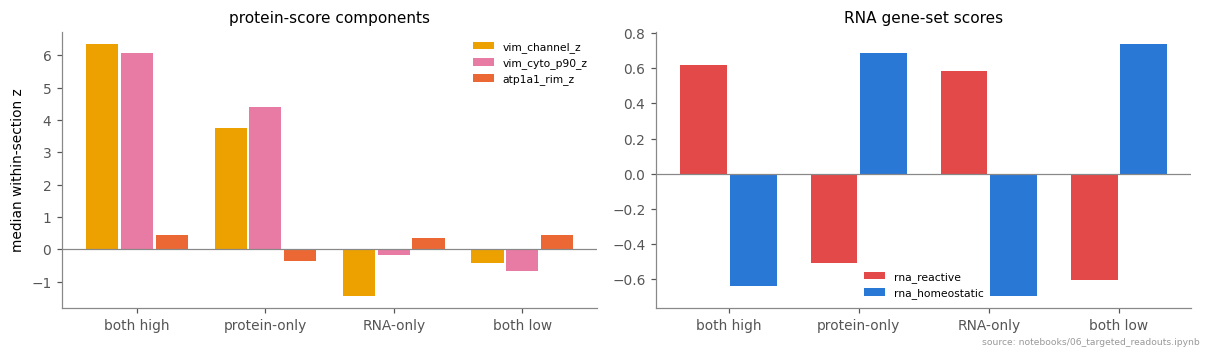

In [3]:
q = lambda s: s.groupby(ast.section_id).transform(lambda x: x.rank(pct=True))
pr, rr = q(ast.prot_score), q(ast.rna_score)
ast["quadrant"] = np.select([(pr > .75) & (rr > .75), (pr < .25) & (rr < .25), (pr > .75) & (rr < .25),
                             (pr < .25) & (rr > .75)],
                            ["both high", "both low", "protein-only", "RNA-only"], "middle")
QUADS = ["both high", "protein-only", "RNA-only", "both low"]
qt = ast[ast.quadrant != "middle"].groupby("quadrant").agg(
    n=("section_id", "size"), lesion_frac=("lesion", "mean"), WM_frac=("region_class", lambda s: (s == "WM").mean()),
    lesion_dist_median=("lesion_dist_um", "median"), edge_um_median=("edge_um", "median"),
    area_median=("morph_cell_area_um2", "median"), transcripts_median=("transcript_counts", "median"),
    vim_channel_z=("z_vim", "median"), vim_cyto_p90_z=("z_vim90", "median"), atp1a1_rim_z=("z_bndrim", "median"),
    rna_reactive_median=("rna_reactive", "median"), rna_homeostatic_median=("rna_homeostatic", "median")).loc[QUADS]
qt.to_csv(OUT / "astro_quadrants.csv")
fig, axs = plt.subplots(1, 2, figsize=(11, 3.2))
comp = qt[["vim_channel_z", "vim_cyto_p90_z", "atp1a1_rim_z"]]
for k, c in enumerate(comp.columns):
    axs[0].bar(np.arange(len(QUADS)) + (k - 1) * 0.27, comp[c], width=0.25, color=plotting.CATEGORICAL[[3, 4, 1][k]], label=c)
axs[0].set_xticks(range(len(QUADS)), QUADS); axs[0].axhline(0, color="#888888", lw=0.8)
axs[0].set_ylabel("median within-section z"); axs[0].legend(fontsize=7); axs[0].set_title("protein-score components")
for k, c in enumerate(["rna_reactive_median", "rna_homeostatic_median"]):
    axs[1].bar(np.arange(len(QUADS)) + (k - 0.5) * 0.38, qt[c], width=0.36, color=plotting.CATEGORICAL[[7, 0][k]],
               label=c.replace("_median", ""))
axs[1].set_xticks(range(len(QUADS)), QUADS); axs[1].axhline(0, color="#888888", lw=0.8)
axs[1].legend(fontsize=7); axs[1].set_title("RNA gene-set scores")
fig.tight_layout()
plotting.save_fig(fig, "astro_quadrant_components", OUT, SRC)
ast[["quadrant", "prot_score", "rna_score", "z_vim", "z_vim90", "z_bndrim"]].to_parquet(ROOT / "data" / "astro_quadrants.parquet")
qt.round(3)

quadrant,both high,protein-only,RNA-only,both low
stage,,,,
CFA,0.147,0.090,0.035,0.728
NONSYMPTOM,0.094,0.064,0.043,0.799
OS1,0.174,0.008,0.062,0.756
MILD16,0.514,0.047,0.069,0.371
PEAK1,0.675,0.037,0.204,0.084
PEAK2,0.713,0.003,0.170,0.114
PEAK3,0.483,0.016,0.118,0.383
SEVERE16,0.539,0.022,0.122,0.317
SEVERE30,0.541,0.034,0.103,0.322


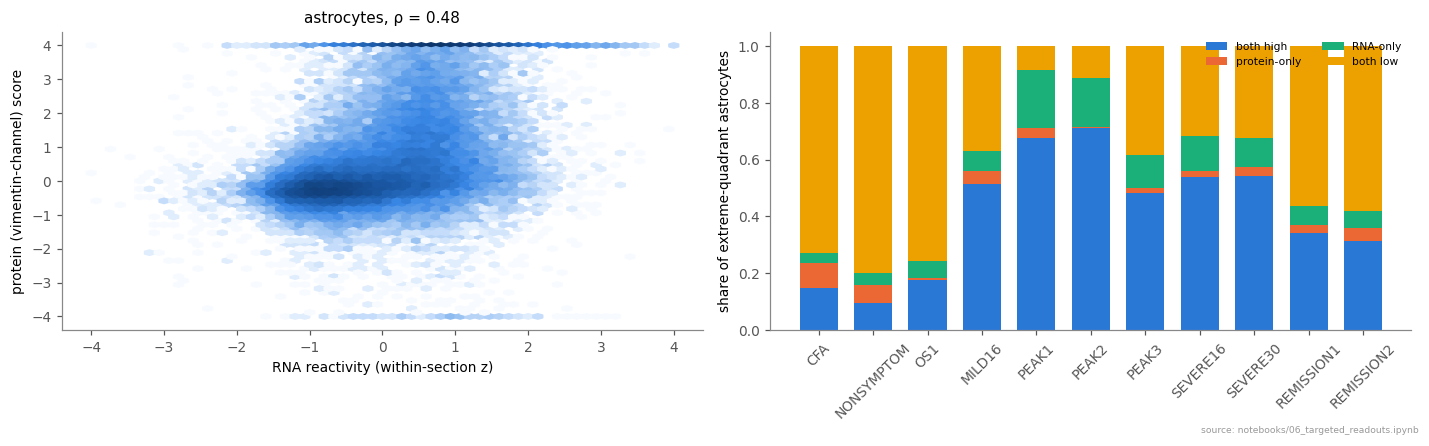

In [4]:
st = ast[ast.quadrant != "middle"].groupby(["stage", "quadrant"], observed=True).size().unstack(fill_value=0)
st = st.div(st.sum(1), axis=0).reindex([s for s in STAGE_ORDER if s in st.index])[QUADS]
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
hb = axs[0].hexbin(ast.rna_score.clip(-4, 4), ast.prot_score.clip(-4, 4), gridsize=60, cmap=plotting.SEQ, bins="log")
axs[0].set(xlabel="RNA reactivity (within-section z)", ylabel="protein (vimentin-channel) score",
           title=f"astrocytes, ρ = {r_all:.2f}")
bottom = np.zeros(len(st))
for k, qd in enumerate(QUADS):
    axs[1].bar(st.index, st[qd], bottom=bottom, color=plotting.CATEGORICAL[k], label=qd, width=0.7)
    bottom += st[qd].values
axs[1].set_ylabel("share of extreme-quadrant astrocytes"); axs[1].tick_params(axis="x", rotation=45)
axs[1].legend(fontsize=7, ncol=2, loc="upper right")
fig.tight_layout()
plotting.save_fig(fig, "astro_protein_vs_rna", OUT, SRC)
st.round(3)

> **Finding — RNA comes before protein.** "RNA-only" astrocytes (reactive transcription, low vimentin) are 95 % in
> lesions and peak in active disease (PEAK1 20 %, PEAK2 17 % of extreme astrocytes vs 3.5 % in CFA), falling in
> remission. "Protein-only" astrocytes (vimentin-high, homeostatic RNA; n = 401) are genuinely vimentin-channel-high
> (z ≈ 3.7–4.4), sit mostly in grey matter outside lesions and are most frequent in CFA / pre-symptomatic animals.

Per animal: protein-only share (of extreme-quadrant astrocytes) vs RNA-only share, by disease phase.
Hypothesis: vimentin protein outlasts the reactive transcriptional programme → protein-only enriched in remission.

In [5]:
pa = ast[ast.quadrant != "middle"].groupby("sample_name", observed=True).agg(
    stage=("stage", "first"), score=("score_sacrifice", "first"), model=("model", "first"),
    protein_only=("quadrant", lambda s: (s == "protein-only").mean()), rna_only=("quadrant", lambda s: (s == "RNA-only").mean()),
    n=("quadrant", "size"))
pa = pa[pa.n >= 50]
pa["phase"] = np.select([pa.stage.astype(str).str.startswith("REMISSION"),
                         pa.stage.astype(str).str.contains("PEAK|SEVERE|MILD|OS1")], ["remission", "active"], "pre/none")
pa["protein_only_minus_rna_only"] = pa.protein_only - pa.rna_only
print(pa.groupby("phase")[["protein_only", "rna_only", "protein_only_minus_rna_only"]].median().round(3))
from scipy.stats import mannwhitneyu
a_, r_ = pa.loc[pa.phase == "active", "protein_only_minus_rna_only"], pa.loc[pa.phase == "remission", "protein_only_minus_rna_only"]
print(f"remission vs active (protein-only − RNA-only): MWU p = {mannwhitneyu(r_, a_).pvalue:.3g} (n={len(r_)} vs {len(a_)})")
pa.to_csv(OUT / "astro_quadrants_per_animal.csv")

           protein_only  rna_only  protein_only_minus_rna_only
phase                                                         
active            0.019     0.111                       -0.082
pre/none          0.064     0.036                        0.037
remission         0.020     0.071                       -0.033
remission vs active (protein-only − RNA-only): MWU p = 0.0194 (n=5 vs 16)


> **Finding — per animal:** protein-only − RNA-only share is negative in active disease (−0.08), smaller in remission
> (−0.03), positive before disease (+0.04); remission vs active p = 0.019 → reactive transcription leads, vimentin
> protein follows/persists.

Gallery: protein-only vs RNA-only astrocytes (one section), same contrast.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/06_targeted_readouts/astro_quadrant_gallery.png')

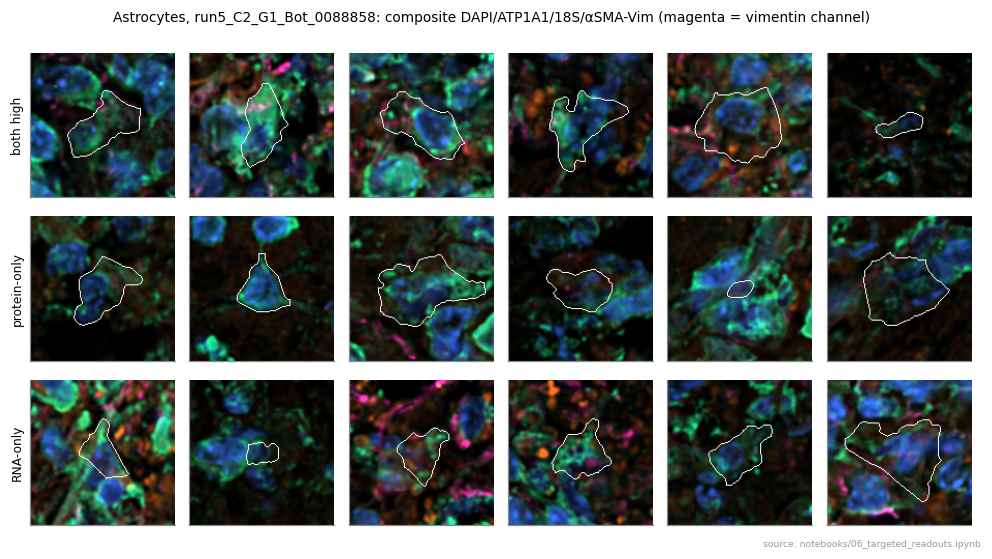

In [6]:
bundles = find_bundles(cfg)
GAL = ast[ast.quadrant.isin(["protein-only", "RNA-only", "both high"])].section_id.value_counts().index[0]
b = XeniumBundle(bundles[GAL])
half = int(15 / 0.2125)
lo = [0.0] * len(CH)
raw = lambda d, ch, st_: d[f"{ch}_{st_}"] * d[f"{ch}_scale"] + d[f"{ch}_bg_local"]
hi = [np.percentile(raw(ast, ch, "cell_p99").dropna(), 99) for ch in CH]
fig, axs = plt.subplots(3, 6, figsize=(9, 5))
for r, qd in enumerate(["both high", "protein-only", "RNA-only"]):
    cells = ast[(ast.section_id == GAL) & (ast.quadrant == qd)]
    cells = cells.sample(min(6, len(cells)), random_state=0)
    for c, (cid, row) in enumerate(cells.iterrows()):
        y, x = int(row.centroid_y_px), int(row.centroid_x_px)
        img, cm, nm = b.read_window(y - half, x - half, 2 * half, 2 * half)
        rgb = plotting.composite(img, CH, lo, hi)
        rgb[find_boundaries(cm == cm[half, half], mode="inner")] = 1
        axs[r, c].imshow(rgb); axs[r, c].set_xticks([]); axs[r, c].set_yticks([])
    axs[r, 0].set_ylabel(qd, fontsize=8)
fig.suptitle(f"Astrocytes, {GAL}: composite DAPI/ATP1A1/18S/αSMA-Vim (magenta = vimentin channel)", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "astro_quadrant_gallery", OUT, SRC)

## 2. Leukocyte polarity: perivascular vs parenchymal
Vessel cells = endothelial + VSMC centroids. Perivascular: nearest vessel cell < 15 µm; parenchymal: > 50 µm.
Magnitude: `*_polarity_shape` (intensity-weighted vs geometric centroid, ÷ radius) and nucleus offset.
Direction: cosine between the polarity vector and the vector to the nearest vessel cell (> 0 = towards the vessel).

In [7]:
vessel = fa.Anno_L1_curated.isin(["Endothelial", "VSMC"])
LEUK = {"MDM": fa.Anno_L2 == "MDM", "Microglia": fa.Anno_L2 == "Microglia", "T cell": fa.Anno_L1_curated == "T cell",
        "DC": fa.Anno_L1_curated == "DC", "B cell": fa.Anno_L1_curated == "B cell"}
fa["vessel_dist_um"], fa["vx"], fa["vy"] = np.nan, np.nan, np.nan
for sec, idx in fa.groupby("section_id", observed=True).indices.items():
    vi = idx[vessel.values[idx]]
    if len(vi) == 0:
        continue
    vxy = fa[["x_centroid", "y_centroid"]].values[vi]
    xy = fa[["x_centroid", "y_centroid"]].values[idx]
    d, j = cKDTree(vxy).query(xy)
    fa.iloc[idx, fa.columns.get_loc("vessel_dist_um")] = d
    fa.iloc[idx, fa.columns.get_loc("vx")] = vxy[j, 0] - xy[:, 0]
    fa.iloc[idx, fa.columns.get_loc("vy")] = vxy[j, 1] - xy[:, 1]
rows = []
for name, m in LEUK.items():
    d = fa[m & (fa.vessel_dist_um > 0)]
    peri, par = d.vessel_dist_um < 15, d.vessel_dist_um > 50
    for ch in CH:
        cosang = (d[f"{ch}_polarity_dx_um"] * d.vx + d[f"{ch}_polarity_dy_um"] * d.vy) / (
            np.hypot(d[f"{ch}_polarity_dx_um"], d[f"{ch}_polarity_dy_um"]) * np.hypot(d.vx, d.vy))
        d = d.assign(cos=cosang)
        pm, p_mag = per_animal_paired(d, f"{ch}_polarity_shape", peri, par)
        cos_an = d[peri].groupby("sample_name", observed=True).cos.agg(["mean", "size"])
        cos_an = cos_an[cos_an["size"] >= 20]["mean"]
        rows.append(dict(cell=name, channel=ch, n_peri=int(peri.sum()), n_par=int(par.sum()),
                         polarity_peri=pm.a.median() if len(pm) else np.nan, polarity_par=pm.b.median() if len(pm) else np.nan,
                         p_magnitude=p_mag, animals=len(pm),
                         cos_towards_vessel_peri=cos_an.median() if len(cos_an) else np.nan,
                         p_direction=wilcoxon(cos_an).pvalue if len(cos_an) >= 5 else np.nan))
pol = pd.DataFrame(rows)
pol.to_csv(OUT / "leukocyte_polarity.csv", index=False)
pol.round(4)

,cell,channel,n_peri,n_par,polarity_peri,polarity_par,p_magnitude,animals,cos_towards_vessel_peri,p_direction
0,MDM,dapi,2953,12423,0.1623,0.1791,0.0244,11,0.0831,0.0322
1,MDM,bnd,2953,12423,0.1773,0.1789,0.2061,11,-0.0831,0.2061
2,MDM,r18s,2953,12423,0.2189,0.2046,0.2783,11,0.0638,0.0020
3,MDM,smavim,2953,12423,0.2926,0.2795,0.6377,11,0.0247,0.4648
4,Microglia,dapi,6564,16938,0.1839,0.1872,0.2996,25,0.0790,0.0000
5,Microglia,bnd,6564,16938,0.1622,0.1706,0.1135,25,-0.0238,0.1073
6,Microglia,r18s,6564,16938,0.2051,0.2030,0.0667,25,0.0453,0.0015
7,Microglia,smavim,6564,16938,0.3380,0.3255,0.0002,25,0.1026,0.0000
8,T cell,dapi,4163,4688,0.1771,0.1737,0.5706,20,0.1084,0.0000
9,T cell,bnd,4163,4688,0.1948,0.1938,0.8983,20,-0.0144,0.3377


> **Finding — polarity magnitude does not differ** between perivascular (< 15 µm to a vessel cell) and parenchymal
> (> 50 µm) leukocytes in a biologically meaningful way. **Direction does:** in leukocytes next to vessels, the 18S
> signal is shifted *towards* the vessel (cos 0.05–0.15, p ≤ 0.002 in MDM, microglia, T cells, DC, B cells).

### Control: is vessel-directed polarity specific to leukocytes, or neighbour bleed?
Same cosine test for non-immune cells next to vessels (< 15 µm). A channel that "points at the vessel" in
neurons and oligodendrocytes too is optical bleed from the vessel/neighbouring nuclei, not cell polarity.

channel,dapi,bnd,r18s,smavim
cells,,,,
T cell,0.108,-0.014,0.142,-0.006
DC,0.111,-0.063,0.145,0.018
B cell,0.046,0.025,0.097,0.029
MDM,0.083,-0.083,0.064,0.025
Microglia,0.079,-0.024,0.045,0.103
Fibroblast,0.113,-0.024,0.168,0.021
Astrocyte,0.063,-0.049,0.016,0.091
Oligodendrocyte,0.044,-0.001,-0.013,0.133
Neuron,0.039,-0.019,0.002,0.096


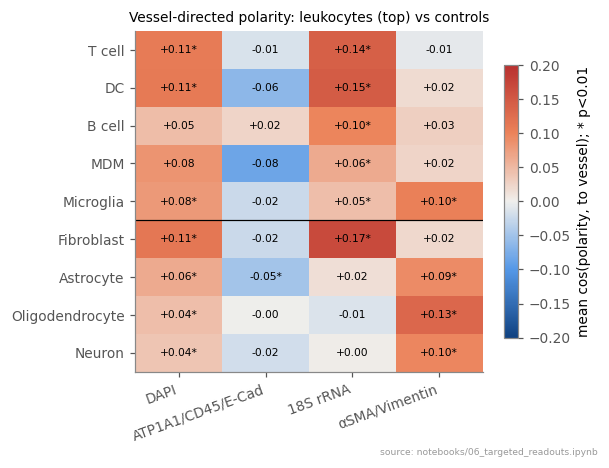

In [8]:
ctrl = {**LEUK, "Fibroblast": fa.Anno_L1_curated == "Fibroblast", "Astrocyte": fa.Anno_L1_curated == "Astrocyte",
        "Oligodendrocyte": fa.Anno_L1_curated == "Oligodendrocyte", "Neuron": fa.Anno_L1_curated == "Neuron"}
rows = []
for name, m in ctrl.items():
    d = fa[m & (fa.vessel_dist_um > 0) & (fa.vessel_dist_um < 15)]
    for ch in CH:
        c = (d[f"{ch}_polarity_dx_um"] * d.vx + d[f"{ch}_polarity_dy_um"] * d.vy) / (
            np.hypot(d[f"{ch}_polarity_dx_um"], d[f"{ch}_polarity_dy_um"]) * np.hypot(d.vx, d.vy))
        an = d.assign(c=c).groupby("sample_name", observed=True).c.agg(["mean", "size"])
        an = an[an["size"] >= 20]["mean"]
        rows.append(dict(cells=name, channel=ch, cos=an.median() if len(an) else np.nan,
                         p=wilcoxon(an).pvalue if len(an) >= 5 else np.nan))
pc = pd.DataFrame(rows)
pc.to_csv(OUT / "polarity_vessel_direction_control.csv", index=False)
pv = pc.pivot(index="cells", columns="channel", values="cos")[CH]
pp_ = pc.pivot(index="cells", columns="channel", values="p")[CH]
order = ["T cell", "DC", "B cell", "MDM", "Microglia", "Fibroblast", "Astrocyte", "Oligodendrocyte", "Neuron"]
pv, pp_ = pv.reindex(order), pp_.reindex(order)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
im = ax.imshow(pv.values, cmap=plotting.DIV, vmin=-0.2, vmax=0.2, aspect="auto")
for i in range(pv.shape[0]):
    for j in range(pv.shape[1]):
        star = "*" if pp_.values[i, j] < 0.01 else ""
        ax.text(j, i, f"{pv.values[i, j]:+.2f}{star}", ha="center", va="center", fontsize=7)
ax.set_xticks(range(len(CH)), [plotting.CHANNEL_LABELS[c] for c in CH], rotation=20, ha="right")
ax.set_yticks(range(len(order)), order)
ax.axhline(4.5, color="black", lw=0.8)
fig.colorbar(im, ax=ax, label="mean cos(polarity, to vessel); * p<0.01", shrink=0.8)
ax.set_title("Vessel-directed polarity: leukocytes (top) vs controls", fontsize=9)
fig.tight_layout()
plotting.save_fig(fig, "polarity_vessel_direction", OUT, SRC)
pv.round(3)

> **Finding — DAPI and αSMA/Vim "polarity towards vessels" is an artefact** (neurons, oligodendrocytes and astrocytes
> show it too: optical bleed from the vessel wall and neighbouring nuclei). **18S towards vessels is cell-type
> specific:** T cells cos 0.14, fibroblasts 0.17 (wrap vessels — partly geometry), MDM 0.06, microglia 0.05, but
> neurons 0.00 and oligodendrocytes −0.01. Images of these T cells in notebook 07.

## 3. 18S per cell type: lesion vs physiological niche
Per animal, median normalised cytoplasmic 18S in lesion vs physiological cells of the same `Anno_L2` type.
Adjusted version: 18S residual after regressing on log transcript density (transcripts / µm²) within type — if the
lesion drop disappears, 18S is tracking RNA quality / capture, not ribosome biology specifically.

In [9]:
fa["tx_density"] = np.log(fa.transcript_counts / fa.morph_cell_area_um2)
rows = []
for t, d in fa.groupby("Anno_L2", observed=True):
    if len(d) < 1000:
        continue
    d = d.copy()
    v = section_z(d.r18s_cyto_mean, d.section_id)
    ok = v.notna()
    beta = np.polyfit(d.tx_density[ok], v[ok], 1)
    d["r18s_z"], d["r18s_adj"] = v, v - np.polyval(beta, d.tx_density)
    d["txd_z"] = section_z(d.tx_density, d.section_id)
    out = {"Anno_L2": t, "n": len(d)}
    for col in ("r18s_z", "r18s_adj", "txd_z"):
        pm, p = per_animal_paired(d, col, d.lesion, d.phys)
        out[f"{col} lesion−phys"] = (pm.a - pm.b).median() if len(pm) else np.nan
        out[f"{col} p"] = p
        out["animals"] = len(pm)
    out["rho r18s~txdensity"] = spearmanr(d.r18s_cyto_mean, d.tx_density, nan_policy="omit").statistic
    rows.append(out)
r18 = pd.DataFrame(rows).dropna(subset=["r18s_z p"]).sort_values("r18s_z lesion−phys")
r18.to_csv(OUT / "r18s_lesion_by_type.csv", index=False)
r18.round(3)

,Anno_L2,n,r18s_z lesion−phys,r18s_z p,animals,r18s_adj lesion−phys,r18s_adj p,txd_z lesion−phys,txd_z p,rho r18s~txdensity
4,Chol,2169,-0.208,0.297,7,-0.240,0.219,-0.035,0.812,0.096
24,OPC/COP,15634,-0.184,0.003,18,0.112,0.016,-0.413,0.000,0.640
15,MOL,47351,-0.135,0.001,20,0.037,0.009,-0.260,0.000,0.610
21,NFOL,11623,-0.049,0.252,16,0.093,0.001,-0.298,0.000,0.650
29,VSMC,9328,0.015,0.985,20,0.059,0.105,-0.052,0.076,0.578
9,Exc,39045,0.027,0.452,20,0.070,0.114,-0.219,0.003,0.343
13,Inh,28696,0.061,0.055,19,0.121,0.007,-0.193,0.001,0.252
20,Mixed,2157,0.147,0.092,12,0.166,0.003,-0.096,0.301,0.600
19,Microglia,50831,0.212,0.000,22,0.212,0.004,-0.050,0.679,0.694
17,Meningeal FBs,11111,0.230,0.358,14,0.254,0.020,-0.179,0.049,0.754


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/06_targeted_readouts/r18s_lesion_by_type.png')

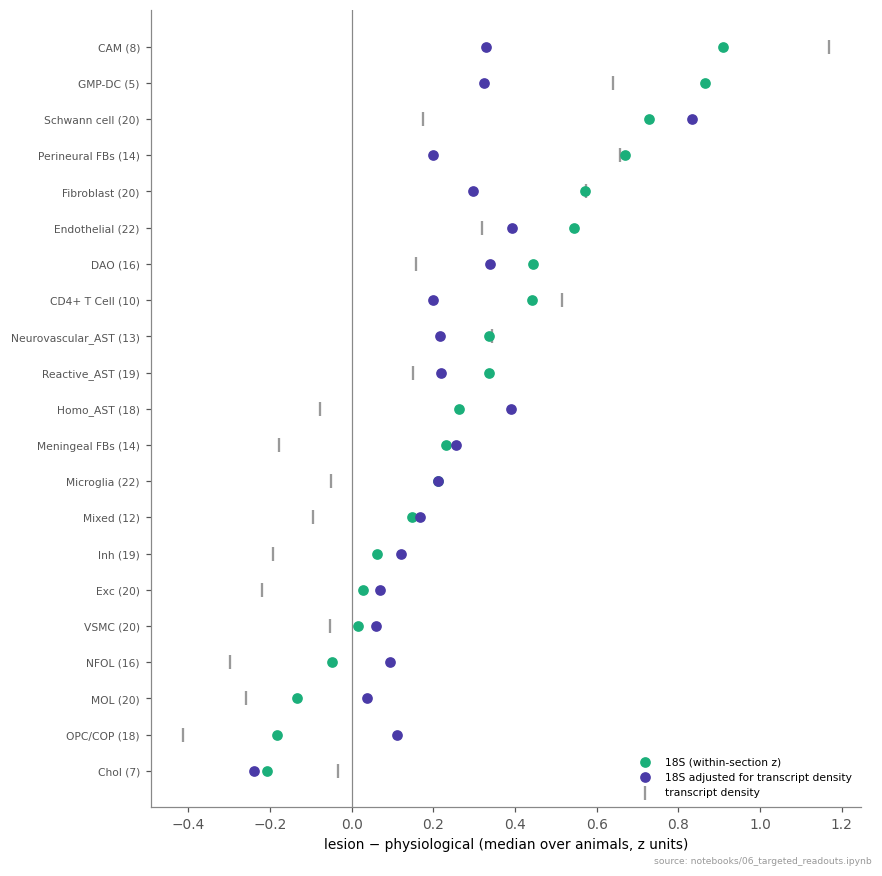

In [10]:
fig, ax = plt.subplots(figsize=(8, 0.32 * len(r18) + 1.2))
y = np.arange(len(r18))
ax.scatter(r18["r18s_z lesion−phys"], y, color=plotting.CATEGORICAL[2], label="18S (within-section z)", zorder=3)
ax.scatter(r18["r18s_adj lesion−phys"], y, color=plotting.CATEGORICAL[6], label="18S adjusted for transcript density", zorder=3)
ax.scatter(r18["txd_z lesion−phys"], y, color="#999999", marker="|", s=80, label="transcript density", zorder=2)
ax.axvline(0, color="#888888", lw=0.8)
ax.set_yticks(y, [f"{t} ({a})" for t, a in zip(r18.Anno_L2, r18.animals)], fontsize=7)
ax.set_xlabel("lesion − physiological (median over animals, z units)")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plotting.save_fig(fig, "r18s_lesion_by_type", OUT, SRC)

> **Finding — 18S rises in activated cells in lesions** (per animal, within-section z): Schwann +0.73, fibroblasts +0.57,
> endothelium +0.54, DAO +0.44, CD4 T +0.44, astrocytes +0.26–0.34, microglia +0.21; it falls in OPC/COP (−0.18) and
> MOL (−0.14). 18S tracks transcript density (ρ 0.6–0.75 within type), but **after adjusting for it the lesion gains
> remain** (endothelium +0.39, Schwann +0.83, astrocytes +0.39) while the oligodendrocyte drop vanishes (MOL +0.04) →
> more ribosomal RNA in activated cells; the oligo loss is RNA-content loss.

## 4. Neuropil-loss index (within tissue piece)
Raw ATP1A1-channel intensity in each cell's 10 µm extracellular territory ÷ the median of all cells in the **same
tissue piece** and region class (WM / GM). Pieces differ in overall ATP1A1 intensity even within a section
(notebook 02), so only within-piece contrasts are interpretable: < 1 = less neuropil ATP1A1 than the rest of the
same piece's WM/GM (loss of neuronal/axonal membrane, oedema, infiltrate).

In [11]:
fa["bnd_terr_raw"] = fa.bnd_terr_mean * fa.bnd_scale + fa.bnd_bg_local
ni = fa[fa.region_class.isin(["WM", "GM"])].copy()
key = ni.meta_sample_id.astype(str) + "|" + ni.region_class
ni["neuropil_index"] = ni.bnd_terr_raw / ni.bnd_terr_raw.groupby(key).transform("median")
by_niche = ni.groupby(["region_class", "Curated_niche_state"], observed=True).neuropil_index.agg(["median", "size"])
by_niche.round(3)

median   size
region_class Curated_niche_state               
GM           Lesion_active         0.984  30892
             Lesion_mix            0.995  16635
             Lesion_progressive    1.053  25282
             Lesion_reactive       0.770   4666
             Physiological         1.000  97636
WM           Lesion_active         0.981  65706
             Lesion_mix            0.916  47502
             Lesion_progressive    1.034  59523
             Physiological         1.147  26876

> **Finding — by niche:** with a within-piece reference, white-matter lesion niches sit below physiological WM (active
> 0.98, mix 0.92 vs physiological 1.15); GM lesions ≈ GM. (A first version referenced per section and was confounded by
> piece-level intensity — replaced.)

Paired within piece: median index of lesion-niche vs physiological-niche cells (pieces with ≥ 100 of each, per
class); Wilcoxon across pieces.

In [12]:
rows = []
for (pc, cl), g in ni.groupby(["meta_sample_id", "region_class"], observed=True):
    L, P = g[g.lesion], g[g.phys]
    if len(L) >= 100 and len(P) >= 100:
        rows.append(dict(piece=pc, region_class=cl, lesion=L.neuropil_index.median(), phys=P.neuropil_index.median(),
                         score=g.score_sacrifice.iloc[0]))
pp = pd.DataFrame(rows)
pp["diff"] = pp.lesion - pp.phys
pp.to_csv(OUT / "neuropil_index_within_piece.csv", index=False)
for cl, g in pp.groupby("region_class"):
    print(f"{cl}: lesion − physiological median {g['diff'].median():+.3f} over {len(g)} pieces, "
          f"Wilcoxon p = {wilcoxon(g['diff']).pvalue:.2g}; ρ(diff, score) = {spearmanr(g['diff'], g.score).statistic:+.2f}")
gl = ni.groupby("Global_niche_group", observed=True).neuropil_index.agg(["median", "size"]).sort_values("median")
gl[gl["size"] >= 500].round(3)

GM: lesion − physiological median +0.003 over 45 pieces, Wilcoxon p = 0.62; ρ(diff, score) = -0.24
WM: lesion − physiological median -0.249 over 38 pieces, Wilcoxon p = 7.9e-06; ρ(diff, score) = +0.01


,median,size
Global_niche_group,,
Dorsal_Rim_DAA,0.840,4567
WM_MOL2,0.852,12409
WM_OPC,0.906,4676
WM,0.944,26062
Lesion_Tcell,0.946,2946
GM,0.949,51340
Lesion_myeloid,0.965,90943
Lesion_DAA,1.006,20393
Disease_GM,1.009,49345


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/06_targeted_readouts/neuropil_index_map.png')

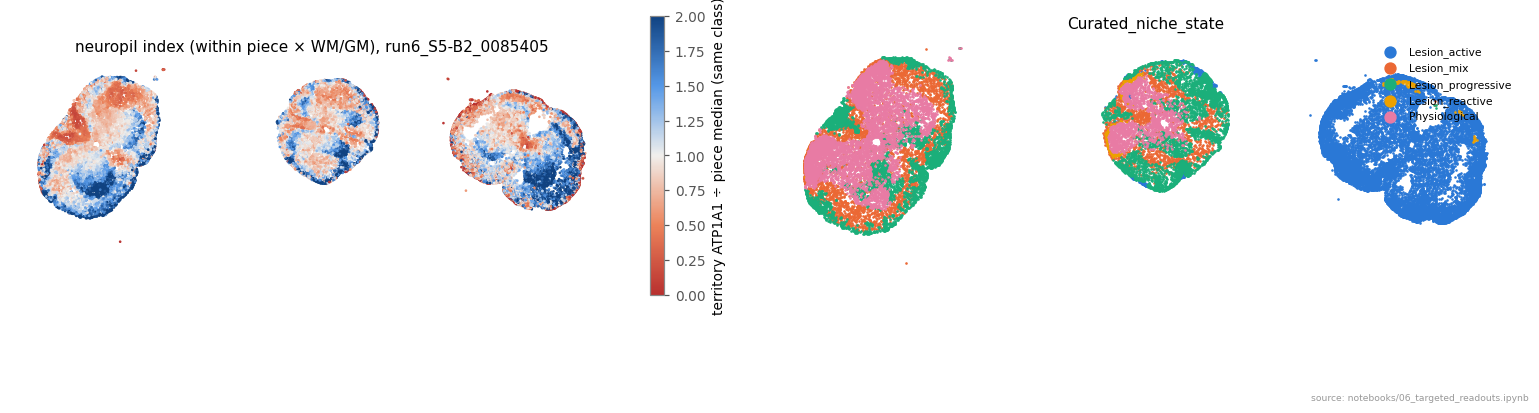

In [13]:
EX = fa[fa.lesion].section_id.value_counts().index[0]
d = ni[ni.section_id == EX]
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))
sc_ = axs[0].scatter(d.x_centroid, -d.y_centroid, c=d.neuropil_index.clip(0, 2), s=0.5, cmap=plotting.DIV.reversed(),
                     vmin=0, vmax=2, rasterized=True)
axs[0].set_title(f"neuropil index (within piece × WM/GM), {EX}"); axs[0].set_aspect("equal"); axs[0].axis("off")
fig.colorbar(sc_, ax=axs[0], shrink=0.6, label="territory ATP1A1 ÷ piece median (same class)")
cats = d.Curated_niche_state.astype(str)
for k, c in enumerate(sorted(cats.unique())):
    m = cats == c
    axs[1].scatter(d.x_centroid[m], -d.y_centroid[m], s=0.5, color=plotting.CATEGORICAL[k % 8], label=c, rasterized=True)
axs[1].set_title("Curated_niche_state"); axs[1].set_aspect("equal"); axs[1].axis("off")
axs[1].legend(markerscale=10, fontsize=7, loc="upper right")
fig.tight_layout()
plotting.save_fig(fig, "neuropil_index_map", OUT, SRC)

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/06_targeted_readouts/neuropil_index_paired.png')

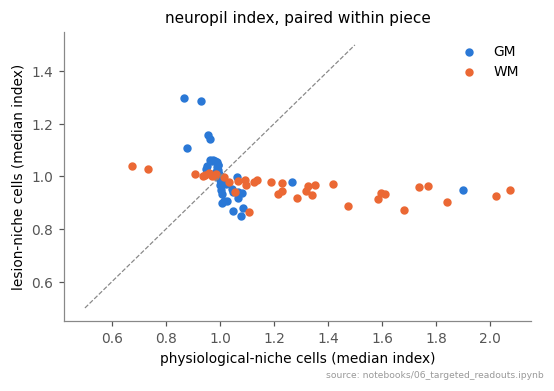

In [14]:
fig, ax = plt.subplots(figsize=(5, 3.5))
for k, (cl, g) in enumerate(pp.groupby("region_class")):
    ax.scatter(g.phys, g.lesion, s=20, color=plotting.CATEGORICAL[k], label=cl)
ax.plot([0.5, 1.5], [0.5, 1.5], color="#888888", lw=0.8, ls="--")
ax.set(xlabel="physiological-niche cells (median index)", ylabel="lesion-niche cells (median index)",
       title="neuropil index, paired within piece")
ax.legend()
fig.tight_layout()
plotting.save_fig(fig, "neuropil_index_paired", OUT, SRC)

> **Finding — neuropil loss in white-matter lesions.** Lesion-niche cells in WM have **25 % less surrounding ATP1A1**
> than physiological WM of the same tissue piece (38 pieces, Wilcoxon p = 8e-6); in GM there is no difference (45
> pieces, p = 0.62). The loss does not scale with clinical score. ATP1A1 (*Atp1a1* is not on the panel) gives a
> tissue-damage readout the transcriptome cannot.